# 2. házi feladat: Célzott és nem célzott poisoning támadás

Készítette:
 - Gegő Levente (LYNUXB)
 - Koleszár Kristóf (I1TLYH)

## Tartalom
1. **Előkészítés** – Adat betöltés, előfeldolgozás, clean + surrogate modellek
2. **1. feladat** – Untargeted poisoning
3. **2. feladat** – Targeted poisoning


## Előkészítés

### Importok és beállítások

In [1]:
!pip install numpy torch scikit-learn matplotlib pandas
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import json
import copy
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")


Device: cpu


### Adat betöltés és előfeldolgozás

In [2]:
# Feature nevek betöltése
with open('nslkdd_features.json', 'r') as f:
    features_info = json.load(f)
col_names = [f['name'] for f in features_info]

# NSL-KDD adathalmaz betöltése
# A fájlokban nincs header, ezért a JSON-ból kinyert feature neveket használjuk
train_df = pd.read_csv('KDDTrain+.txt', header=None, names=col_names)
test_df  = pd.read_csv('KDDTest+.txt',  header=None, names=col_names)
print(f"Train: {train_df.shape}, Test: {test_df.shape}")

# Bináris címkézés: a feladatleírás szerint normal=0, minden támadás=1
train_df['binary_label'] = (train_df['label'] != 'normal').astype(int)
test_df['binary_label']  = (test_df['label']  != 'normal').astype(int)

print("Train label:", train_df['binary_label'].value_counts().to_dict())
print("Test label:",  test_df['binary_label'].value_counts().to_dict())


Train: (125973, 43), Test: (22544, 43)
Train label: {0: 67343, 1: 58630}
Test label: {1: 12833, 0: 9711}


In [3]:
# One-hot encoding a kategorikus oszlopokra
categorical_cols = ['protocol_type', 'service', 'flag']

# Train és test kombinálása az encoding előtt
# Azért kell kombinálni, mert a tesztben lehetnek olyan kategorikus értékek
# amik a trainben nincsenek, így konzisztens lesz a kódolás
combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
combined_encoded = pd.get_dummies(combined, columns=categorical_cols)

# Vissza szétválasztás train-re és test-re
train_enc = combined_encoded.iloc[:len(train_df)].copy()
test_enc = combined_encoded.iloc[len(train_df):].copy().reset_index(drop=True)

# Feature mátrixok és címkék kinyerése
# label, difficulty és binary_label nem feature-ök, ezeket eldobjuk
drop_cols = ['label', 'difficulty', 'binary_label']
feature_cols = [c for c in train_enc.columns if c not in drop_cols]

X_train_full = train_enc[feature_cols].values.astype(np.float32)
y_train_full = train_enc['binary_label'].values.astype(np.float32)
X_test_all = test_enc[feature_cols].values.astype(np.float32)
y_test_all = test_enc['binary_label'].values.astype(np.float32)

input_dim = X_train_full.shape[1]
print(f"Feature number: {input_dim}")


Feature number: 122


In [4]:
# StandardScaler: train adaton fit-eljük, mindkét halmazra transform
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full).astype(np.float32)
X_test_all = scaler.transform(X_test_all).astype(np.float32)

# Train - Validation felosztás, 80%-20% arányban
# Stratified split, hogy az osztályeloszlás megmaradjon
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)

# Feature min/max értékek a tanítóadatból
# Ezekre clamp-eljük majd a WiB támadás poison mintáit
feat_min = X_train.min(axis=0)
feat_max = X_train.max(axis=0)

print(f"Train: {X_train.shape} (normal={int((y_train==0).sum())}, attack={int((y_train==1).sum())})")
print(f"Validation:   {X_val.shape} (normal={int((y_val==0).sum())}, attack={int((y_val==1).sum())})")
print(f"Test:  {X_test_all.shape} (normal={int((y_test_all==0).sum())}, attack={int((y_test_all==1).sum())})")


Train: (100778, 122) (normal=53874, attack=46904)
Validation:   (25195, 122) (normal=13469, attack=11726)
Test:  (22544, 122) (normal=9711, attack=12833)


### Modell architektúra és segédfüggvények

In [5]:
from IDS import IntrusionDetector

# Az IDS.py-ban lévő train_model() függvény test adatot is vár paraméterként
# és epoch-onként printeli az eredményeket. Poisoningnál rengeteg újratanítás kell,
# úgyhogy csináltam egy egyszerűbb változatot ami csendben tanít.
# A hiperparaméterek a feladatleírásból:
#   Adam optimizer, lr=0.001, batch_size=128, 10 epoch, BCEWithLogitsLoss
def train_ids(X_tr, y_tr, epochs=10, batch_size=128, lr=0.001, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    X_t = torch.FloatTensor(X_tr).to(device)
    y_t = torch.FloatTensor(y_tr).unsqueeze(1).to(device)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    model = IntrusionDetector(X_tr.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()

    return model

# Predikció: a modell logit-ot ad ki, sigmoid után 0.5 küszöbbel döntünk
def predict(model, X):
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(torch.FloatTensor(X).to(device)))
        return (probs > 0.5).float().cpu().numpy().flatten()

def get_accuracy(model, X, y):
    return accuracy_score(y, predict(model, X))

### Clean modell és 5 surrogate modell tanítása

In [6]:
# Clean modell: amit meg akarunk támadni IDS, a 80%-os train adaton tanítva
print("Clean modell tanítása")
clean_model = train_ids(X_train, y_train, seed=SEED)
clean_train_acc = get_accuracy(clean_model, X_train, y_train)
clean_val_acc = get_accuracy(clean_model, X_val, y_val)
print(f"Clean modell - Train accuracy: {clean_train_acc:.4f}, Validation acc: {clean_val_acc:.4f}")

# 5 surrogate modell tanítása a teszt adaton
# A feladatleírás szerint a támadó hozzáfér a tesztadathoz és azon tanít surrogate-eket
# Minden modell más seed-del indul -> más random inicializálás és mini-batch sorrend
print("\n5 surrogate modell tanítása")
surrogates = []
for i in range(5):
    s = train_ids(X_test_all, y_test_all, seed=i * 1000 + 42)
    s_acc = get_accuracy(s, X_test_all, y_test_all)
    print(f"Surrogate {i+1}: test accuracy = {s_acc:.4f}")
    surrogates.append(s)

Clean modell tanítása
Clean modell - Train accuracy: 0.9959, Validation acc: 0.9951

5 surrogate modell tanítása
Surrogate 1: test accuracy = 0.9766
Surrogate 2: test accuracy = 0.9755
Surrogate 3: test accuracy = 0.9764
Surrogate 4: test accuracy = 0.9755
Surrogate 5: test accuracy = 0.9756


## 1. feladat: Untargeted Poisoning

A támadó célja a validációs accuracy rontása. Az ötlet: a tanítóadat p%-át kiválasztjuk, a címkéiket invertáljuk (attack↔normal), majd ezeket az átcímkézett mintákat hozzáadjuk a tanítóadathoz. Az így kibővített adaton tanítjuk újra a modellt.

### Task 1: Véletlenszerű kiválasztás

In [7]:
p_values = [30, 50, 70]
q1_results = {p: [] for p in p_values}

for p in p_values:
    for trial in range(5):
        seed_t = trial * 111 + p
        np.random.seed(seed_t)

        # p% véletlenszerűen kiválasztott minta, invertált címkével hozzáadva
        n_poison = int(len(y_train) * p / 100)
        idx = np.random.choice(len(y_train), size=n_poison, replace=False)

        # Ezeket invertált címkével hozzáadjuk a tanítóadathoz
        X_poisoned = np.concatenate([X_train, X_train[idx]])
        y_poisoned = np.concatenate([y_train, 1.0 - y_train[idx]])

        # Újratanítás a szennyezett adaton, más seed-del minden trial-hoz
        model_p = train_ids(X_poisoned, y_poisoned, seed=seed_t)
        val_a = get_accuracy(model_p, X_val, y_val)
        q1_results[p].append(val_a)

    print(f"p={p}%: mean={np.mean(q1_results[p]):.4f} ± {np.std(q1_results[p]):.4f}")
    print(f"values={[f'{v:.4f}' for v in q1_results[p]]}")


p=30%: mean=0.9904 ± 0.0008
values=['0.9915', '0.9903', '0.9907', '0.9904', '0.9890']
p=50%: mean=0.9886 ± 0.0008
values=['0.9885', '0.9897', '0.9891', '0.9886', '0.9873']
p=70%: mean=0.9827 ± 0.0033
values=['0.9794', '0.9782', '0.9840', '0.9866', '0.9851']


### Task 2: Loss-alapú kiválasztás

In [8]:
# Loss-based kiválasztáshoz minden tanító mintára kiszámoljuk a loss-t
# az invertált címkére nézve, mind az 5 surrogate modellen
# A nagy invertált loss azt jelenti, hogy a surrogate-ek nagyon biztosak az eredeti címkében,
# vagyis ezek átcímkézése okozza a legnagyobb zavart
criterion_none = nn.BCEWithLogitsLoss(reduction='none') # reduction=none jelenti a mintánkénti loss-t
X_t_tr = torch.FloatTensor(X_train).to(device)
y_inv = torch.FloatTensor(1.0 - y_train).unsqueeze(1).to(device)

all_losses = []
for sm in surrogates:
    sm.eval()
    with torch.no_grad():
        out = sm(X_t_tr)
        l = criterion_none(out, y_inv).cpu().numpy().flatten()
        all_losses.append(l)

# 5 surrogate átlaga mintánként
avg_inv_loss = np.mean(all_losses, axis=0)
print(f"Inverted loss statisztikák: mean={avg_inv_loss.mean():.4f}, "
      f"min={avg_inv_loss.min():.4f}, max={avg_inv_loss.max():.4f}")


Inverted loss statisztikák: mean=11.9018, min=0.0000, max=622.1893


In [9]:
q2_results = {p: [] for p in p_values}

for p in p_values:
    # A legnagyobb átlagos invertált loss-ú mintákat választjuk ki (felső p%)
    # Ezek azok amikben a surrogate-ek a legbiztosabbak, az ő átcímkézésük a legdestruktívabb
    n_poison = int(len(y_train) * p / 100)
    idx = np.argsort(avg_inv_loss)[-n_poison:]

    # Hozzáadjuk invertált címkével
    X_poisoned = np.concatenate([X_train, X_train[idx]])
    y_poisoned = np.concatenate([y_train, 1.0 - y_train[idx]])

    # A poison minták fixek, csak a tanítás randomizált
    for trial in range(5):
        seed_t = trial * 222 + p
        model_p = train_ids(X_poisoned, y_poisoned, seed=seed_t)
        val_a = get_accuracy(model_p, X_val, y_val)
        q2_results[p].append(val_a)

    print(f"p={p}%: mean={np.mean(q2_results[p]):.4f} ± {np.std(q2_results[p]):.4f}")
    print(f"values={[f'{v:.4f}' for v in q2_results[p]]}")


p=30%: mean=0.9838 ± 0.0008
values=['0.9827', '0.9831', '0.9843', '0.9847', '0.9845']
p=50%: mean=0.8341 ± 0.0906
values=['0.8399', '0.9550', '0.8425', '0.8594', '0.6739']
p=70%: mean=0.6908 ± 0.0445
values=['0.6944', '0.7032', '0.6903', '0.7523', '0.6137']


### Box plot összehasonlítás

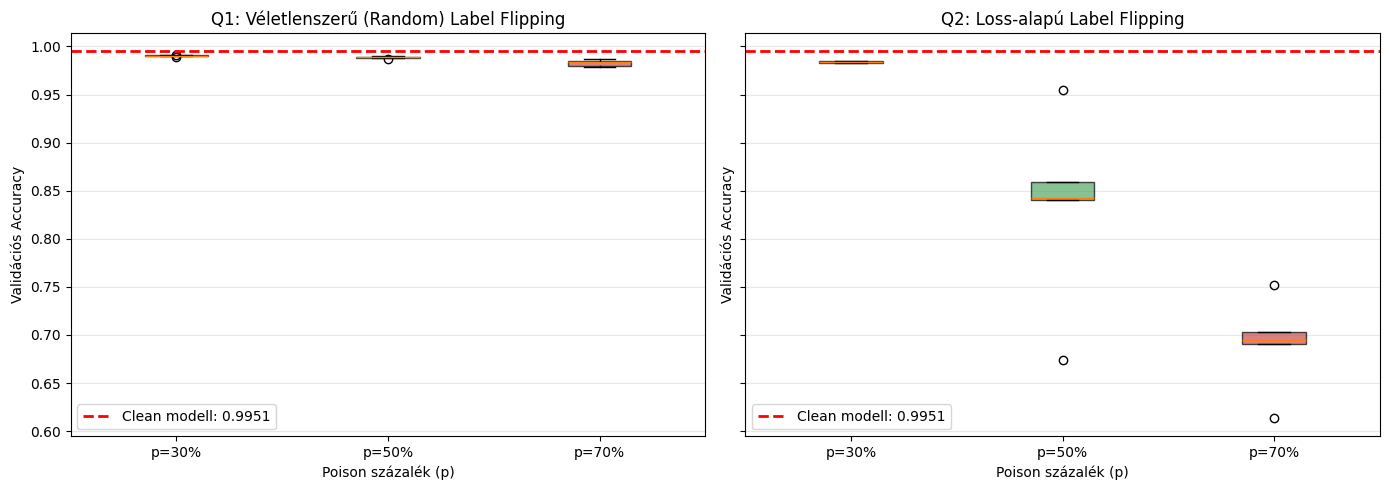

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, data, title in [
    (axes[0], q1_results, 'Q1: Véletlenszerű (Random) Label Flipping'),
    (axes[1], q2_results, 'Q2: Loss-alapú Label Flipping')
]:
    bp = ax.boxplot([data[p] for p in p_values],
                    labels=[f'p={p}%' for p in p_values], patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(clean_val_acc, color='red', ls='--', lw=2,
               label=f'Clean modell: {clean_val_acc:.4f}')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Validációs Accuracy')
    ax.set_xlabel('Poison százalék (p)')
    ax.legend(loc='lower left')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('boxplot_task1.png', dpi=150, bbox_inches='tight')
plt.show()


### Task 3: Hasonlítsa össze a fenti két esetben kapott eredményeket! Melyik hatékonyabb és miért?

A loss-based módszer egyértelműen hatékonyabb. A random kiválasztásnál még p=70%-nál is csak 0.9829-re csökken a validációs accuracy (a clean 0.9948-ról), ami alig észrevehető romlás. Ezzel szemben a loss-based módszer p=50%-nál már 0.8292-re rontja, p=70%-nál pedig 0.6857-re – ez már közel használhatatlan modell.

Az ok az, hogy a loss-based módszer a surrogate modelleken számolt invertált loss alapján célzottan azokat a mintákat választja ki, amelyek a döntési határ közelében vannak; ezek átcímkézése a legnagyobb zavart okozza a tanítás során. A random kiválasztás viszont rengeteg "egyértelmű" mintát is átcímkéz (pl. nyilvánvaló DoS támadásokat), amiknek az invertálása nem zavaró, mert a modell könnyen felismeri hogy nem illenek a másik osztályba.

Érdemes azt is megjegyezni, hogy a loss-based módszernél a szórás is nagyobb (p=50%-nál 0.6731–0.8776 közötti értékek), ami azt mutatja, hogy a random inicializálás erősen befolyásolja, hogy mennyire hat a mérgezett adat a modell döntési határára.


### Task 4: Elemezze a támadások megvalósíthatóságát a gyakorlatban! Javasoljon bármilyen védekezést amivel a támadás sikeressége csökkenthető (nem kell implementálni)!

A támadás megvalósíthatósága a gyakorlatban korlátozott, mert feltételezi, hogy a támadó hozzáfér a teljes tanítóadathoz, illetve képes mintákat hozzáadni anélkül hogy bárki észrevenné, valamint a loss-based változatnál ismeri a modell architektúráját is surrogate tanításhoz. Mindhárom feltétel együttes teljesülése ritka, de nem lehetetlen, például crowdsourced adatgyűjtésnél, nyílt threat intelligence feed-eknél, vagy ha a támadó közvetlenül a hálózati forgalmat manipulálja amiből az IDS tanul.

Védekezési lehetőségek közé tartozik egyrészt a tanítóadaton futtatott anomália-detekció vagy outlier szűrés, ami kiszűrheti a gyanúsan átcímkézett mintákat (pl. egy egyértelmű DoS forgalom ami "normal" címkével van ellátva). Másik lehetőség a cross-validation alapú szűrés, hiszen ha egy minta több fold-ban is konzisztensen rosszul klasszifikálódik, valószínűleg hibás a címkéje. A DP-SGD (differenciálisan privát tanítás) szintén segíthet, mivel a gradient clipping és a zajhozzáadás csökkenti az egyes minták hatását, így a poison minták kevésbé tudják eltolni a modellt. Egy további egyszerű heurisztika, hogy ha a tanítóadat mérete hirtelen megnő, az már gyanús lehet.

## 2. feladat: Targeted Poisoning

A cél, hogy 10 kiválasztott target mintát rosszul soroljunk be a szennyezett modellel. A WiB támadás lényege, hogy a poison mintákon számolt gradiens illeszkedjen a target minta invertált címkével számolt gradiensével. Így a tanítás során a poison minták "szimulálják" a target átcímkézésének hatását, anélkül hogy a target ténylegesen benne lenne a tanítóadatban.


### Target minták kiválasztása

In [11]:
# Target minták kiválasztása a feladatleírás feltételei szerint:
# 1. Teszt adatból származnak és nem validációsból
# 2. Eredetileg attack (y=1) címkéjűek
# 3. A clean IDS helyesen klasszifikálja őket támadásként
# 4. A loss értékük y_adv=0 (normal) címkére minimális
# -> ezek olyan támadások, amikben a clean modell amúgy is bizonytalan

clean_model.eval()
clean_preds = predict(clean_model, X_test_all)

# Feltétel 2 és 3
attack_correct_mask = (y_test_all == 1) & (clean_preds == 1)
candidate_idx = np.where(attack_correct_mask)[0]
print(f"Helyes támadások: {len(candidate_idx)}")

# Feltétel 4
# A kis loss azt jelenti, hogy a modell kimenete közel van a 0-hoz = bizonytalan hogy attack-e
with torch.no_grad():
    X_cand_t = torch.FloatTensor(X_test_all[candidate_idx]).to(device)
    y_adv_cand = torch.zeros(len(candidate_idx), 1).to(device)
    out_cand = clean_model(X_cand_t)
    loss_on_normal = nn.BCEWithLogitsLoss(reduction='none')(out_cand, y_adv_cand)
    loss_on_normal = loss_on_normal.cpu().numpy().flatten()

# Top 10 legkisebb loss → leginkább bizonytalan
top10 = np.argsort(loss_on_normal)[:10]
target_indices = candidate_idx[top10]

print(f"\n10 target index: {target_indices}")
print(f"Loss értékek y_adv=0 esetén: {np.round(loss_on_normal[top10], 4)}")
print(f"Eredeti címkék: {y_test_all[target_indices]}")

X_targets = X_test_all[target_indices]
y_targets = y_test_all[target_indices]
y_adv = 0.0  # A támadó célja, hogy ezeket normalnak klasszifikálja a modell


Helyes támadások: 9025

10 target index: [16960  6149 20560 15396 18721 11839   512  4282  6546  8944]
Loss értékek y_adv=0 esetén: [0.6967 0.6997 0.7031 0.7085 0.7113 0.7147 0.7331 0.7371 0.7419 0.7449]
Eredeti címkék: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Segédfüggvények a gradiens számításhoz

In [12]:
# Kiszámítja a BCE loss gradiensét a modell paramétereire nézve
#egy adott (x, y_label) mintára.
# A WiB támadásnál a poison minták deltáit úgy optimalizáljuk,
# hogy a poison gradiens illeszkedjen a target gradienssel.
# Ehhez kell create_graph=True, hogy a delta-kon keresztül is
# tudjon backpropagálni

def get_param_grad(model, x, y_label, create_graph=False):
    model.eval()
    for param in model.parameters():
        param.requires_grad_(True)

    x_in = x.unsqueeze(0) if x.dim() == 1 else x
    if not create_graph:
        x_in = x_in.detach()
    x_in = x_in.to(next(model.parameters()).device)
    y_in = torch.tensor([[float(y_label)]], dtype=torch.float32, device=x_in.device)

    output = model(x_in)
    loss = nn.BCEWithLogitsLoss()(output, y_in)

    # Gradiens az összes modell paraméterre, egyetlen vektorrá lapítva
    params = [p for p in model.parameters() if p.requires_grad]
    grads = torch.autograd.grad(loss, params, create_graph=create_graph)
    return torch.cat([g.flatten() for g in grads])

### Base minták kiválasztása

In [13]:
#Base minták kiválasztása a teszthalmazból a WiB támadáshoz.
# A feladatleírás szerint a base minták:
# y_adv_t címkéjűek (normal, y=0)
# Gradiens koszinusz hasonlóság alapján választjuk a legjobbakat
# Az 5 surrogate modell átlagos hasonlóságát nézzük
def select_base_samples(target_x, y_adv_t, X_test, y_test, surrogates, p_count):
    cand_mask = (y_test == y_adv_t)
    cand_idx = np.where(cand_mask)[0]
    print(f"Candidates (y={y_adv_t}): {len(cand_idx)}")

    target_grads = []
    x_t = torch.FloatTensor(target_x).to(device)
    for model in surrogates:
        g = get_param_grad(model, x_t, y_adv_t, create_graph=False)
        target_grads.append(g.detach())
        for param in model.parameters():
            param.requires_grad_(False)

    avg_sims = np.zeros(len(cand_idx))
    for bi in range(len(cand_idx)):
        ci = cand_idx[bi]
        x_c = torch.FloatTensor(X_test[ci]).to(device)
        sims = []
        for j, model in enumerate(surrogates):
            g_c = get_param_grad(model, x_c, y_test[ci], create_graph=False)
            for param in model.parameters():
                param.requires_grad_(False)
            sim = F.cosine_similarity(
                target_grads[j].unsqueeze(0), g_c.unsqueeze(0)
            ).item()
            sims.append(sim)
        avg_sims[bi] = np.mean(sims)
        if (bi + 1) % 1000 == 0:
            print(f"Progress: {bi+1}/{len(cand_idx)}")

    # Top p_count minta a legnagyobb átlagos hasonlósággal
    top_p_idx = np.argsort(avg_sims)[-p_count:][::-1]
    selected = cand_idx[top_p_idx]
    sims_selected = avg_sims[top_p_idx]
    print(f"Kiválasztott {p_count} base minta, "
          f"cos sim: [{sims_selected[-1]:.4f}, {sims_selected[0]:.4f}]")
    return selected

### Witches' Brew PGD támadás

In [14]:
# Witches' Brew targeted poisoning támadás.
#
# A cél: delta perturbációkat találni a base mintákra úgy, hogy a poison minták
# gradiense (a modell paramétereire nézve) illeszkedjen a target minta
# y_adv címkével számolt gradiensével.
#
# Az alignment loss fv-t a feladatleírásból vettem át
def witches_brew_attack(target_x, y_adv_t, base_indices, X_test, y_test,
                         surrogates, feat_min_np, feat_max_np, max_iter=1000):
    p = len(base_indices)
    fmin = torch.FloatTensor(feat_min_np).to(device)
    fmax = torch.FloatTensor(feat_max_np).to(device)

    # Target gradiensek előszámítása, fixek
    x_target = torch.FloatTensor(target_x).to(device)
    target_grads = []
    for model in surrogates:
        g = get_param_grad(model, x_target, y_adv_t, create_graph=False)
        target_grads.append(g.detach())
        for param in model.parameters():
            param.requires_grad_(False)

    # Base minták és a hozzájuk tartozó delta perturbációk inicializálása
    # A delta-k nulláról indulnak, ezeket kell optimalizálni
    base_tensors = []
    base_labels = []
    deltas = []
    for i in range(p):
        bx = torch.FloatTensor(X_test[base_indices[i]]).to(device).detach()
        base_tensors.append(bx)
        base_labels.append(float(y_test[base_indices[i]]))
        delta = torch.zeros_like(bx, requires_grad=True)
        deltas.append(delta)

    # SGD optimalizáció a delta-kra, ReduceLROnPlateau scheduler-rel
    optimizer = torch.optim.SGD(deltas, lr=0.1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=75, eps=1e-06
    )

    best_loss = float('inf')
    best_deltas = [d.data.clone() for d in deltas]

    for it in range(max_iter):
        optimizer.zero_grad()

        total_loss = torch.zeros(1, device=device)[0]

        for j, model in enumerate(surrogates):
            model.eval()
            for param in model.parameters():
                param.requires_grad_(True)

            for i in range(p):
                # Poison minta = base + delta, feature határokra clamp-elve
                poison_x = torch.clamp(base_tensors[i] + deltas[i], fmin, fmax)

                # Gradiens a modell paramétereire nézve
                g_poison = get_param_grad(
                    model, poison_x, base_labels[i], create_graph=True
                )

                # Alignment: koszinusz hasonlóság a target és poison gradiens közt
                cos_sim = F.cosine_similarity(
                    target_grads[j].unsqueeze(0),
                    g_poison.unsqueeze(0)
                )
                total_loss = total_loss + (1.0 - cos_sim.squeeze())

        # Normalizálás a surrogate-ek számával
        total_loss = total_loss / 5.0
        total_loss.backward()

        optimizer.step()
        scheduler.step(total_loss.item())

        ## Surrogate modell paraméterek gradiensének törlése, hogy ne zavarják a delta-k optimalizációját
        for model in surrogates:
            model.zero_grad()
            for param in model.parameters():
                param.requires_grad_(False)

        # Projekció: base+delta a [feat_min, feat_max] tartományban maradjon
        with torch.no_grad():
            for i in range(p):
                clamped = torch.clamp(base_tensors[i] + deltas[i], fmin, fmax)
                deltas[i].data = clamped - base_tensors[i]

        # Legjobb deltak mentése
        loss_val = total_loss.item()
        if loss_val < best_loss:
            best_loss = loss_val
            best_deltas = [d.data.clone() for d in deltas]

        if it % 200 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"Iter {it}/{max_iter}: loss={loss_val:.6f}, lr={lr_now:.6f}")

    print(f"Best loss: {best_loss:.6f}")

    # Végleges poison minták összeállítása a legjobb delta-kkal
    poison_X = []
    poison_y = []
    for i in range(p):
        px = torch.clamp(base_tensors[i] + best_deltas[i], fmin, fmax)
        poison_X.append(px.cpu().numpy())
        poison_y.append(base_labels[i])
    return np.array(poison_X, dtype=np.float32), np.array(poison_y, dtype=np.float32)

### Támadás végrehajtása

In [15]:
targeted_results = {}

# Először kiszámítjuk a base mintákat minden target-re
# p=15-re keresünk, p=5 esetén az első 5 legjobbat használjuk ezekből
print("Base minták számítása minden target-re")
all_base_idx = {}
for t_pos, t_idx in enumerate(target_indices):
    print("\nTarget " + str(t_pos+1) + "/10 (test index=" + str(t_idx) + ") base kiválasztás...")
    base_idx_15 = select_base_samples(
        X_test_all[t_idx], y_adv, X_test_all, y_test_all, surrogates, p_count=15
    )
    all_base_idx[t_idx] = base_idx_15

# Támadás végrehajtása p=5 és p=15 base mintával
for p_base in [5, 15]:
    print("Targeted poisoning: p = " + str(p_base) + " base minta target-enként")

    successes = 0

    for t_pos, t_idx in enumerate(target_indices):
        print("\nTarget " + str(t_pos+1) + "/10 (test index=" + str(t_idx) + ")")

        # p=5 esetén csak az első 5 base mintát használjuk (a legnagyobb cos sim-mel)
        base_idx = all_base_idx[t_idx][:p_base]

        print("WiB PGD")
        poison_X, poison_y = witches_brew_attack(
            X_test_all[t_idx], y_adv, base_idx,
            X_test_all, y_test_all, surrogates,
            feat_min, feat_max, max_iter=1000
        )

        # A poison mintákat hozzáadjuk a tanítóadathoz és újratanítjuk a modellt
        X_poisoned = np.concatenate([X_train, poison_X])
        y_poisoned = np.concatenate([y_train, poison_y])

        # Újratanítás random inicializálással
        retrained = train_ids(X_poisoned, y_poisoned, seed=int(t_idx) + 9999)

        # A támadás akkor sikeres, ha a target mintát az újratanított modell normalnak klasszifikálja
        pred = predict(retrained, X_test_all[t_idx:t_idx+1])

        is_success = (pred[0] == y_adv)
        if is_success:
            successes += 1

        result_str = "SIKERES" if is_success else "SIKERTELEN"
        print("Predikció: " + str(int(pred[0])) + ", Cél: " + str(int(y_adv)) + " -> " + result_str)

    attack_rate = successes / 10
    targeted_results[p_base] = {'successes': successes, 'rate': attack_rate}
    print("\nTámadás sikeressége p=" + str(p_base) + ": " + str(successes) + "/10 = " + f"{attack_rate:.0%}")

Base minták számítása minden target-re

Target 1/10 (test index=16960) base kiválasztás...
Candidates (y=0.0): 9711
Progress: 1000/9711
Progress: 2000/9711
Progress: 3000/9711
Progress: 4000/9711
Progress: 5000/9711
Progress: 6000/9711
Progress: 7000/9711
Progress: 8000/9711
Progress: 9000/9711
Kiválasztott 15 base minta, cos sim: [0.0767, 0.6369]

Target 2/10 (test index=6149) base kiválasztás...
Candidates (y=0.0): 9711
Progress: 1000/9711
Progress: 2000/9711
Progress: 3000/9711
Progress: 4000/9711
Progress: 5000/9711
Progress: 6000/9711
Progress: 7000/9711
Progress: 8000/9711
Progress: 9000/9711
Kiválasztott 15 base minta, cos sim: [0.4737, 0.6468]

Target 3/10 (test index=20560) base kiválasztás...
Candidates (y=0.0): 9711
Progress: 1000/9711
Progress: 2000/9711
Progress: 3000/9711
Progress: 4000/9711
Progress: 5000/9711
Progress: 6000/9711
Progress: 7000/9711
Progress: 8000/9711
Progress: 9000/9711
Kiválasztott 15 base minta, cos sim: [0.4595, 0.7762]

Target 4/10 (test index=1539

### 2.6 Eredmények összefoglalása

Összefoglaló eredmények:

Clean modell validációs accuracy: 0.9951

1. feladat: Untargeted Poisoning
Módszer                        p=30%      p=50%      p=70%
-------------------------------------------------------
Random                        0.9904     0.9886     0.9827
Loss-based                    0.9838     0.8341     0.6908

2. feladat: Targeted Poisoning (WiB)
  p=5: 8/10 sikeresen félreklasszifikálva (80%)
  p=15: 10/10 sikeresen félreklasszifikálva (100%)


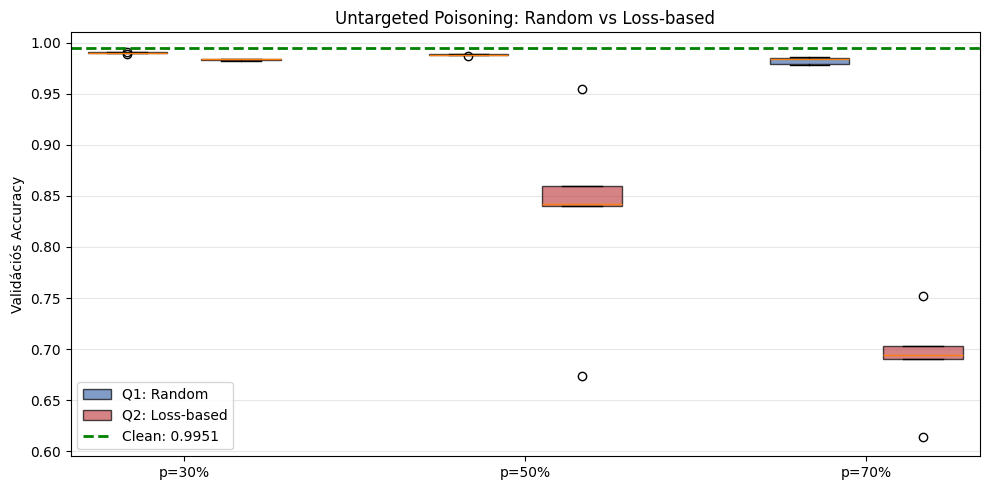

In [16]:
print("Összefoglaló eredmények:")

print(f"\nClean modell validációs accuracy: {clean_val_acc:.4f}")

print(f"\n1. feladat: Untargeted Poisoning")
print(f"{'Módszer':<25} {'p=30%':>10} {'p=50%':>10} {'p=70%':>10}")
print("-" * 55)
print(f"{'Random':<25} "
      f"{np.mean(q1_results[30]):>10.4f} "
      f"{np.mean(q1_results[50]):>10.4f} "
      f"{np.mean(q1_results[70]):>10.4f}")
print(f"{'Loss-based':<25} "
      f"{np.mean(q2_results[30]):>10.4f} "
      f"{np.mean(q2_results[50]):>10.4f} "
      f"{np.mean(q2_results[70]):>10.4f}")

print(f"\n2. feladat: Targeted Poisoning (WiB)")
for p_b, res in targeted_results.items():
    print(f"  p={p_b}: {res['successes']}/10 sikeresen félreklasszifikálva ({res['rate']:.0%})")

# Combined box plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
positions_q1 = [1, 4, 7]
positions_q2 = [2, 5, 8]

bp1 = ax.boxplot([q1_results[p] for p in p_values], positions=positions_q1,
                  patch_artist=True, widths=0.7)
bp2 = ax.boxplot([q2_results[p] for p in p_values], positions=positions_q2,
                  patch_artist=True, widths=0.7)

for patch in bp1['boxes']:
    patch.set_facecolor('#4C72B0'); patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#C44E52'); patch.set_alpha(0.7)

ax.axhline(clean_val_acc, color='green', ls='--', lw=2, label=f'Clean: {clean_val_acc:.4f}')
ax.set_xticks([1.5, 4.5, 7.5])
ax.set_xticklabels(['p=30%', 'p=50%', 'p=70%'])
ax.set_ylabel('Validációs Accuracy')
ax.set_title('Untargeted Poisoning: Random vs Loss-based')
ax.legend([bp1['boxes'][0], bp2['boxes'][0], ax.lines[-1]],
          ['Q1: Random', 'Q2: Loss-based', f'Clean: {clean_val_acc:.4f}'],
          loc='lower left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('combined_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 2. feladat Q2: Gyakorlati elemzés és védekezés

A Witches' Brew támadás az untargeted-nél jóval erősebb feltételezésekkel él, mert az architektúra és hiperparaméterek ismeretén túl surrogate modelleket is kell tanítani, poison mintákat kell craft-olni second-order gradiensekkel, és mindezt target-enként 1000 PGD iteráción keresztül. A gyakorlatban ez a feltételrendszer ritkán áll fenn, bár federated learning vagy közös adatmegosztásos környezetekben elképzelhető.

Az eredmények is mutatják a támadás korlátait: a target 5 és 9 esetében p=5-nél a best loss 1.59 és 0.88 maradt, ami azzal függ össze, hogy ezeknél a base minták koszinusz hasonlósága alacsony volt (0.04–0.07 tartomány). Vagyis ha a támadónak nincs elég hasonló mintája a teszthalmazban, a gradiens-illesztés nem konvergál eléggé és a támadás megbukik. Ugyanakkor p=15-re már mind a 10 target sikerült, tehát több base mintával kompenzálni lehet a gyengébb illeszkedést.

Védekezésként az 1. feladatnál említett DP-SGD itt is releváns, de a WiB ellen specifikusabb módszerek is léteznek. A spectral signatures megközelítés azon alapul, hogy a poison minták jellemzően hasonló irányba tolják el a belső reprezentációkat, ami PCA-val detektálható a tanítóadaton. Szintén hatékony lehet több random inicializálással tanított modell aggregálása (ensemble), mivel a WiB támadás egy konkrét tanítási trajektóriát céloz meg, és ensemble esetén az egyes modellek eltérő trajektóriái nehezítik a célzott manipulációt. Végül a tanítóadat növekedésének monitorozása és az új minták eloszlásának statisztikai ellenőrzése is segíthet a poison minták kiszűrésében.